# CCR-GNN Baseline for DMF

Notebook này train kiến trúc Graph theo bài báo **Every Corporation Owns Its Structure: Corporate Credit Ratings via Graph Neural Networks**. Thay vì xây graph giữa các công ty bằng kNN/temporal edges, mỗi dòng/công ty được ánh xạ thành một graph riêng: node là từng chiều feature trong corporate embedding, cạnh feature-feature được tạo bằng self-outer-product, sau đó GAT học tương tác local và graph pooling lấy thông tin global.

Output chính vẫn là `gat_val_predictions.csv` và `gat_test_predictions.csv` để notebook DMF/DCS join với LSTM theo `row_id`.

## Notebook Contract
- Input canonical trên Kaggle: `/kaggle/input/datasets/tailength/corporate-credit-rating/test/{train,val,test}.csv`.
- Output writable: `/kaggle/working/credit_rating_artifacts/`.
- DMF/DCS contract: prediction CSV giữ `row_id`, `ticker`, `rating_date`, true/pred labels, confidence, `prob_0..prob_n`, và `label_mapping.csv`.
- Graph contract: dùng CCR-GNN/C2G adapted cho dữ liệu này, gồm feature-node graph mỗi dòng, self-outer-product adjacency, 3 GAT layer, pooling mean/mean/max, concat local + global trước MLP.
- Class 0 là lớp thiểu số cần theo dõi riêng; notebook chọn checkpoint bằng score có `Class0_F2`, dùng mild class-0 weighting + margin loss nhẹ, và calibrate threshold class 0 bằng validation trước khi đánh giá/export test.


In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, cohen_kappa_score,
    confusion_matrix, classification_report,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start


PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Project root:', PROJECT_ROOT)
print('DMF artifact dir:', DMF_ARTIFACT_DIR)


Device: cpu
Project root: /kaggle/working
DMF artifact dir: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm


In [2]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']


def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')


TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv',
    ['data/processed/test/train.csv'],
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv',
    ['data/processed/test/val.csv'],
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv',
    ['data/processed/test/test.csv'],
)


def load_split(path, split_name):
    frame = pd.read_csv(path)
    frame = frame.copy()
    frame['__split__'] = split_name
    frame['__split_row_index__'] = np.arange(len(frame), dtype=int)
    if 'row_id' not in frame.columns:
        frame['row_id'] = [f'{split_name}_{i:06d}' for i in range(len(frame))]
    else:
        frame['row_id'] = frame['row_id'].astype(str)
    return frame


train_df = load_split(TRAIN_PATH, 'train')
val_df = load_split(VAL_PATH, 'val')
test_df = load_split(TEST_PATH, 'test')
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_contract = {
    'train_path': str(TRAIN_PATH),
    'val_path': str(VAL_PATH),
    'test_path': str(TEST_PATH),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>',
}
print('DMF split contract:', split_contract)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for i, v in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
label_contract = pd.DataFrame({
    'label_id': list(range(n_classes)),
    'label_name': [str(id_to_raw.get(i, i)) for i in range(n_classes)],
})
label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
if 'ticker' not in df.columns:
    df['ticker'] = 'UNKNOWN'
df['ticker'] = df['ticker'].fillna('UNKNOWN').astype(str)
if 'company_name' not in df.columns:
    df['company_name'] = df['ticker']
df['company_name'] = df['company_name'].fillna(df['ticker']).astype(str)

sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask_raw = df['__split__'].eq('train')
stats_ref = df.loc[train_mask_raw].copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date', '__split__', '__split_row_index__']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

df['last_y'] = df.groupby('ticker')[TARGET_COL].shift(1)
df['last_y'] = df['last_y'].fillna(df[TARGET_COL]).astype(int)

x_all = torch.tensor(df[MODEL_FEATURES].values.astype(np.float32), dtype=torch.float32, device=device)
y_all = torch.tensor(df[TARGET_COL].values.astype(int), dtype=torch.long, device=device)
last_y_all = torch.tensor(df['last_y'].values.astype(int), dtype=torch.long, device=device)
sector_all = torch.tensor(df['sector_id'].values.astype(int), dtype=torch.long, device=device)

train_mask = torch.tensor(df['__split__'].eq('train').values, dtype=torch.bool, device=device)
val_mask = torch.tensor(df['__split__'].eq('val').values, dtype=torch.bool, device=device)
test_mask = torch.tensor(df['__split__'].eq('test').values, dtype=torch.bool, device=device)

train_class_counts = torch.bincount(y_all[train_mask], minlength=n_classes).float()
train_class_weights = train_class_counts.sum() / train_class_counts.clamp_min(1.0)
train_class_weights = train_class_weights / train_class_weights.mean().clamp_min(1e-12)

# Class 0 is rare. Full inverse-frequency weights over-correct on this split, so
# the final loss uses a capped, class-0-only CE weight instead.
class0_mild_weights = torch.ones(n_classes, dtype=torch.float32, device=device)
if n_classes > 0:
    class0_mild_weights[0] = 1.25

print('Train class counts:', train_class_counts.detach().cpu().numpy().astype(int).tolist())
print('Train inverse-frequency weights:', np.round(train_class_weights.detach().cpu().numpy(), 4).tolist())
print('Mild class-0 weights used by final loss:', np.round(class0_mild_weights.detach().cpu().numpy(), 4).tolist())

print('Rows train/val/test:', int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))
print('n_classes:', n_classes, '| n_sectors:', n_sectors, '| n_features:', len(MODEL_FEATURES))


DMF split contract: {'train_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv', 'val_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv', 'test_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv', 'train_rows': 6029, 'val_rows': 862, 'test_rows': 1723, 'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>'}
Train class counts: [207, 1957, 3865]
Train inverse-frequency weights: [2.5876998901367188, 0.2736999988555908, 0.13860000669956207]
Mild class-0 weights used by final loss: [1.25, 1.0, 1.0]
Rows train/val/test: 6029 862 1723
n_classes: 3 | n_sectors: 12 | n_features: 24


In [3]:
CLASS0_LABEL_ID = 0

CLASS0_THRESHOLD_CONFIG = {
    'enabled': True,
    'metric': 'Class0_F2',
    'accuracy_floor_drop': 0.015,
    'threshold_grid': np.round(np.arange(0.05, 0.501, 0.01), 2).tolist(),
}


def predict_with_class0_threshold(proba, class0_threshold=None):
    pred = np.asarray(proba).argmax(axis=1).astype(int)
    if class0_threshold is None:
        return pred
    promote_mask = np.asarray(proba)[:, CLASS0_LABEL_ID] >= float(class0_threshold)
    pred[promote_mask] = CLASS0_LABEL_ID
    return pred


def compute_metrics(y_true, y_pred, proba, n_cls, last_y=None):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    acc = accuracy_score(y_true_arr, y_pred_arr)
    f1m = f1_score(y_true_arr, y_pred_arr, average='macro', zero_division=0)
    f1w = f1_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    prec = precision_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    rec = recall_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    class_prec, class_rec, class_f1, class_support = precision_recall_fscore_support(
        y_true_arr,
        y_pred_arr,
        labels=list(range(n_cls)),
        zero_division=0,
    )
    c0_precision = float(class_prec[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_prec) else float('nan')
    c0_recall = float(class_rec[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_rec) else float('nan')
    c0_f1 = float(class_f1[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_f1) else float('nan')
    c0_support = int(class_support[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_support) else 0
    if c0_precision + c0_recall > 0:
        c0_f2 = float(5.0 * c0_precision * c0_recall / (4.0 * c0_precision + c0_recall))
    else:
        c0_f2 = 0.0
    qwk = cohen_kappa_score(y_true_arr, y_pred_arr, weights='quadratic')
    try:
        y_bin = label_binarize(y_true_arr, classes=list(range(n_cls)))
        auc_score = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc_score = float('nan')
    ordinal_mae = np.mean(np.abs(y_true_arr - y_pred_arr))
    # ChgAcc: accuracy on samples where label changed vs last known rating.
    if last_y is not None:
        last_y_arr = np.asarray(last_y)
        change_mask = last_y_arr != y_true_arr
        if change_mask.sum() > 0:
            chg_acc = float(accuracy_score(y_true_arr[change_mask], y_pred_arr[change_mask]))
        else:
            chg_acc = float('nan')
    else:
        chg_acc = float('nan')
    return {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'Class0_Precision': c0_precision,
        'Class0_Recall': c0_recall,
        'Class0_F1': c0_f1,
        'Class0_F2': c0_f2,
        'Class0_Support': c0_support,
        'AUC': float(auc_score),
        'QWK': float(qwk),
        'ChgAcc': chg_acc,
        'Ordinal_MAE': float(ordinal_mae),
    }


def evaluate_logits(logits, mask, class0_threshold=None):
    probs = torch.softmax(logits[mask], dim=1).detach().cpu().numpy()
    y_true = y_all[mask].detach().cpu().numpy()
    y_pred = predict_with_class0_threshold(probs, class0_threshold=class0_threshold)
    last_y_np = last_y_all[mask].detach().cpu().numpy()
    return compute_metrics(y_true, y_pred, probs, n_classes, last_y=last_y_np), y_true, y_pred, probs


def selection_score(metrics):
    chg_acc = 0.0 if np.isnan(metrics['ChgAcc']) else metrics['ChgAcc']
    return (
        0.60 * metrics['Accuracy']
        + 0.15 * metrics['QWK']
        + 0.10 * metrics['Macro_F1']
        + 0.10 * metrics['Class0_F2']
        + 0.05 * chg_acc
        - 0.05 * metrics['Ordinal_MAE']
    )


def calibrate_class0_threshold(y_true, proba, last_y=None, config=None):
    config = config or CLASS0_THRESHOLD_CONFIG
    baseline_pred = predict_with_class0_threshold(proba, class0_threshold=None)
    baseline_metrics = compute_metrics(y_true, baseline_pred, proba, n_classes, last_y=last_y)
    rows = []
    for threshold in config['threshold_grid']:
        pred = predict_with_class0_threshold(proba, class0_threshold=threshold)
        metrics = compute_metrics(y_true, pred, proba, n_classes, last_y=last_y)
        rows.append({'class0_threshold': float(threshold), **metrics})
    sweep_df = pd.DataFrame(rows)
    accuracy_floor = baseline_metrics['Accuracy'] - float(config.get('accuracy_floor_drop', 0.01))
    candidates = sweep_df[sweep_df['Accuracy'] >= accuracy_floor].copy()
    if candidates.empty:
        candidates = sweep_df.copy()
    sort_cols = [config.get('metric', 'Class0_F2'), 'Accuracy', 'Macro_F1', 'QWK']
    best_row = candidates.sort_values(sort_cols, ascending=False).iloc[0]
    best_threshold = float(best_row['class0_threshold'])
    return best_threshold, sweep_df, baseline_metrics, best_row.to_dict()


In [4]:
# CCR-GNN / Corporation-to-Graph configuration from Feng et al. (2012.01933v1).
# Paper mapping adapted to this notebook:
# - one rating row is one corporate graph;
# - feature nodes are dimensions of [financial features, last-rating embedding, sector embedding];
# - adjacency is built from self-outer-product magnitude and a connected backbone;
# - GFIL uses 3 GAT layers with mean/mean/max graph pooling.

LAST_Y_EMB_DIM = 8
SECTOR_EMB_DIM = 8
CCR_GNN_LAYER_DIMS = (8, 64, n_classes)
CCR_GNN_POOLING = ('mean', 'mean', 'max')
C2G_THRESHOLD_QUANTILE = 0.80
C2G_USE_ABS_OUTER_PRODUCT = True

FEATURE_NODE_NAMES = (
    list(MODEL_FEATURES)
    + [f'last_y_emb_{i}' for i in range(LAST_Y_EMB_DIM)]
    + [f'sector_emb_{i}' for i in range(SECTOR_EMB_DIM)]
)

# Kept as None so downstream code cannot accidentally reuse the old inter-company graph.
edge_index = None
edge_df = pd.DataFrame(columns=['src', 'dst', 'src_feature', 'dst_feature'])

c2g_contract = {
    'paper': 'CCR-GNN / corporation-to-graph, arXiv:2012.01933v1',
    'row_graph': 'one graph per rating row/company observation',
    'node_count': len(FEATURE_NODE_NAMES),
    'node_sources': {
        'financial_and_delta_features': len(MODEL_FEATURES),
        'last_rating_embedding_dims': LAST_Y_EMB_DIM,
        'sector_embedding_dims': SECTOR_EMB_DIM,
    },
    'adjacency': 'self_outer_product_threshold + self_loops + feature-chain backbone for connected graph',
    'threshold_quantile': C2G_THRESHOLD_QUANTILE,
    'gat_layer_dims': CCR_GNN_LAYER_DIMS,
    'pooling': CCR_GNN_POOLING,
}
print('CCR-GNN graph contract:', c2g_contract)


CCR-GNN graph contract: {'paper': 'CCR-GNN / corporation-to-graph, arXiv:2012.01933v1', 'row_graph': 'one graph per rating row/company observation', 'node_count': 40, 'node_sources': {'financial_and_delta_features': 24, 'last_rating_embedding_dims': 8, 'sector_embedding_dims': 8}, 'adjacency': 'self_outer_product_threshold + self_loops + feature-chain backbone for connected graph', 'threshold_quantile': 0.8, 'gat_layer_dims': (8, 64, 3), 'pooling': ('mean', 'mean', 'max')}


In [5]:
class DenseFeatureGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=1, dropout=0.2, concat=False, negative_slope=0.2):
        super().__init__()
        self.heads = int(heads)
        self.out_dim = int(out_dim)
        self.concat = bool(concat)
        self.lin = nn.Linear(in_dim, out_dim * self.heads, bias=False)
        self.attn_src = nn.Parameter(torch.empty(self.heads, out_dim))
        self.attn_dst = nn.Parameter(torch.empty(self.heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(out_dim * self.heads if self.concat else out_dim))
        self.dropout = nn.Dropout(dropout)
        self.negative_slope = float(negative_slope)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.attn_src)
        nn.init.xavier_uniform_(self.attn_dst)
        nn.init.zeros_(self.bias)

    def forward(self, node_features, adjacency):
        # node_features: [batch, feature_nodes, channels]
        batch_size, n_nodes, _ = node_features.shape
        h = self.lin(node_features).view(batch_size, n_nodes, self.heads, self.out_dim)
        src_scores = (h * self.attn_src.view(1, 1, self.heads, self.out_dim)).sum(-1).permute(0, 2, 1)
        dst_scores = (h * self.attn_dst.view(1, 1, self.heads, self.out_dim)).sum(-1).permute(0, 2, 1)
        scores = dst_scores.unsqueeze(-1) + src_scores.unsqueeze(-2)
        scores = F.leaky_relu(scores, negative_slope=self.negative_slope)
        scores = scores.masked_fill(~adjacency.unsqueeze(1), -1e9)
        alpha = self.dropout(torch.softmax(scores, dim=-1))
        out = torch.einsum('bhij,bjho->biho', alpha, h)
        if self.concat:
            out = out.reshape(batch_size, n_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=2)
        return out + self.bias


class CCRGNN(nn.Module):
    def __init__(
        self,
        n_features,
        n_classes,
        n_sectors,
        layer_dims=(8, 64, 3),
        pooling=('mean', 'mean', 'max'),
        dropout=0.25,
        last_y_emb_dim=8,
        sector_emb_dim=8,
        context_dropout=0.15,
        c2g_threshold_quantile=0.80,
        use_abs_outer_product=True,
    ):
        super().__init__()
        if len(layer_dims) != len(pooling):
            raise ValueError('layer_dims va pooling phai co cung do dai.')
        self.context_dropout = float(context_dropout)
        self.c2g_threshold_quantile = float(c2g_threshold_quantile)
        self.use_abs_outer_product = bool(use_abs_outer_product)
        self.n_features = int(n_features)
        self.last_y_emb_dim = int(last_y_emb_dim)
        self.last_y_emb = nn.Embedding(n_classes, last_y_emb_dim)
        self.sector_emb = nn.Embedding(n_sectors, sector_emb_dim)
        self.node_count = int(n_features + last_y_emb_dim + sector_emb_dim)
        self.input_norm = nn.LayerNorm(self.node_count)
        self.pooling = tuple(pooling)

        dims = [1, *[int(d) for d in layer_dims]]
        self.gat_layers = nn.ModuleList([
            DenseFeatureGATLayer(dims[i], dims[i + 1], heads=1, dropout=dropout, concat=False)
            for i in range(len(layer_dims))
        ])
        self.gat_residuals = nn.ModuleList([
            nn.Identity() if dims[i] == dims[i + 1] else nn.Linear(dims[i], dims[i + 1], bias=False)
            for i in range(len(layer_dims))
        ])
        self.gat_norms = nn.ModuleList([nn.LayerNorm(int(dim)) for dim in layer_dims])
        self.layer_dropout = nn.Dropout(dropout * 0.5)
        readout_dim = self.node_count * (1 + sum(layer_dims)) + sum(layer_dims)
        self.head = nn.Sequential(
            nn.LayerNorm(readout_dim),
            nn.Dropout(dropout),
            nn.Linear(readout_dim, 128),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def build_node_values(self, x, last_y, sector_id):
        last_y_emb = self.last_y_emb(last_y)
        corporate_embedding = torch.cat([x, last_y_emb, self.sector_emb(sector_id)], dim=1)
        corporate_embedding = self.input_norm(corporate_embedding)
        return corporate_embedding.unsqueeze(-1)

    def apply_context_dropout(self, node_values):
        if not self.training or self.context_dropout <= 0:
            return node_values
        values = node_values.squeeze(-1).clone()
        start = self.n_features
        end = start + self.last_y_emb_dim
        values[:, start:end] = F.dropout(values[:, start:end], p=self.context_dropout, training=True)
        return values.unsqueeze(-1)

    def c2g_adjacency(self, node_values):
        # Non-differentiable graph construction mirrors the paper's thresholded C2G step.
        with torch.no_grad():
            values = node_values.squeeze(-1)
            scores = values.unsqueeze(2) * values.unsqueeze(1)
            if self.use_abs_outer_product:
                scores = scores.abs()
            n_nodes = scores.size(1)
            eye = torch.eye(n_nodes, device=scores.device, dtype=torch.bool)
            off_diag = ~eye
            off_scores = scores[:, off_diag]
            if off_scores.numel() == 0:
                adjacency = eye.unsqueeze(0).expand(scores.size(0), -1, -1).clone()
            else:
                thresholds = torch.quantile(
                    off_scores,
                    q=self.c2g_threshold_quantile,
                    dim=1,
                    keepdim=True,
                ).view(-1, 1, 1)
                adjacency = scores >= thresholds
                adjacency = adjacency | eye.unsqueeze(0)
                if n_nodes > 1:
                    chain = torch.zeros((n_nodes, n_nodes), device=scores.device, dtype=torch.bool)
                    idx = torch.arange(n_nodes - 1, device=scores.device)
                    chain[idx, idx + 1] = True
                    chain[idx + 1, idx] = True
                    adjacency = adjacency | chain.unsqueeze(0)
        return adjacency

    @staticmethod
    def graph_pool(node_features, mode):
        if mode == 'mean':
            return node_features.mean(dim=1)
        if mode == 'max':
            return node_features.max(dim=1).values
        raise ValueError(f'Pooling khong ho tro: {mode}')

    def forward(self, x, last_y, sector_id, edge_index=None, return_embeddings=False):
        node_values = self.build_node_values(x, last_y, sector_id)
        adjacency = self.c2g_adjacency(node_values)
        node_values = self.apply_context_dropout(node_values)
        local_reps = [node_values]
        global_reps = []
        h = node_values
        for layer, residual, norm, pool_mode in zip(self.gat_layers, self.gat_residuals, self.gat_norms, self.pooling):
            h_next = F.elu(layer(h, adjacency))
            h = norm(h_next + residual(h))
            h = self.layer_dropout(h)
            local_reps.append(h)
            global_reps.append(self.graph_pool(h, pool_mode))
        local_readout = torch.cat([rep.reshape(rep.size(0), -1) for rep in local_reps], dim=1)
        global_readout = torch.cat(global_reps, dim=1)
        readout = torch.cat([local_readout, global_readout], dim=1)
        logits = self.head(readout)
        if return_embeddings:
            return logits, readout
        return logits


CreditGAT = CCRGNN


class RampedFocalOrdinalLoss(nn.Module):
    def __init__(
        self,
        n_classes,
        class_weights=None,
        ce_weight=1.0,
        focal_gamma=0.25,
        focal_weight=0.015,
        ordinal_weight=0.003,
        class0_margin_weight=0.02,
        class0_margin=0.10,
        warmup_epochs=100,
    ):
        super().__init__()
        self.n_classes = int(n_classes)
        self.ce_weight = float(ce_weight)
        self.focal_gamma = float(focal_gamma)
        self.focal_weight = float(focal_weight)
        self.ordinal_weight = float(ordinal_weight)
        self.class0_margin_weight = float(class0_margin_weight)
        self.class0_margin = float(class0_margin)
        self.warmup_epochs = max(1, int(warmup_epochs))
        if class_weights is None:
            self.register_buffer('class_weights', None)
        else:
            self.register_buffer('class_weights', class_weights.detach().float().clone())
        self.register_buffer('class_positions', torch.arange(self.n_classes, dtype=torch.float32))

    def ramp(self, epoch=None):
        if epoch is None:
            return 1.0
        return min(1.0, max(0.0, float(epoch) / float(self.warmup_epochs)))

    def class0_margin_loss(self, logits, targets):
        class0_mask = targets.eq(0)
        if class0_mask.sum() == 0 or logits.size(1) <= 1:
            return logits.new_tensor(0.0)
        class0_logits = logits[class0_mask, 0]
        competitor_logits = logits[class0_mask, 1:].max(dim=1).values
        class0_margin = class0_logits - competitor_logits
        return F.softplus(self.class0_margin - class0_margin).mean()

    def forward(self, logits, targets, epoch=None):
        targets = targets.long()
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()

        ce_per_sample = F.nll_loss(log_probs, targets, weight=self.class_weights, reduction='none')
        ce_loss = ce_per_sample.mean()

        pt = probs.gather(1, targets.view(-1, 1)).squeeze(1).clamp_min(1e-8)
        focal_loss = ((1.0 - pt) ** self.focal_gamma * ce_per_sample).mean()

        distances = torch.abs(self.class_positions.to(logits.device).view(1, -1) - targets.float().view(-1, 1))
        ordinal_loss = (probs * distances).sum(dim=1)
        if self.n_classes > 1:
            ordinal_loss = ordinal_loss / float(self.n_classes - 1)
        ordinal_loss = ordinal_loss.mean()

        margin_loss = self.class0_margin_loss(logits, targets)
        ramp = self.ramp(epoch)
        return self.ce_weight * ce_loss + ramp * (
            self.focal_weight * focal_loss
            + self.ordinal_weight * ordinal_loss
            + self.class0_margin_weight * margin_loss
        )


model = CreditGAT(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    layer_dims=CCR_GNN_LAYER_DIMS,
    pooling=CCR_GNN_POOLING,
    dropout=0.25,
    last_y_emb_dim=LAST_Y_EMB_DIM,
    sector_emb_dim=SECTOR_EMB_DIM,
    context_dropout=0.15,
    c2g_threshold_quantile=C2G_THRESHOLD_QUANTILE,
    use_abs_outer_product=C2G_USE_ABS_OUTER_PRODUCT,
).to(device)

LOSS_CONFIG = {
    'ce_weight': 1.0,
    'focal_gamma': 0.25,
    'focal_weight': 0.015,
    'ordinal_weight': 0.003,
    'class0_margin_weight': 0.02,
    'class0_margin': 0.10,
    'warmup_epochs': 100,
    'use_mild_class0_weights': True,
}
criterion = RampedFocalOrdinalLoss(
    n_classes=n_classes,
    class_weights=class0_mild_weights if LOSS_CONFIG['use_mild_class0_weights'] else None,
    ce_weight=LOSS_CONFIG['ce_weight'],
    focal_gamma=LOSS_CONFIG['focal_gamma'],
    focal_weight=LOSS_CONFIG['focal_weight'],
    ordinal_weight=LOSS_CONFIG['ordinal_weight'],
    class0_margin_weight=LOSS_CONFIG['class0_margin_weight'],
    class0_margin=LOSS_CONFIG['class0_margin'],
    warmup_epochs=LOSS_CONFIG['warmup_epochs'],
).to(device)
OPTIMIZER_CONFIG = {
    'lr': 1.2e-3,
    'weight_decay': 3e-5,
    'plateau_factor': 0.55,
    'plateau_patience': 8,
    'min_lr': 1e-5,
}
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=OPTIMIZER_CONFIG['lr'],
    weight_decay=OPTIMIZER_CONFIG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=OPTIMIZER_CONFIG['plateau_factor'],
    patience=OPTIMIZER_CONFIG['plateau_patience'],
    min_lr=OPTIMIZER_CONFIG['min_lr'],
)
print('CCR-GNN config:', c2g_contract)
print('Loss config:', LOSS_CONFIG)
print('Optimizer config:', OPTIMIZER_CONFIG)
print(model)


CCR-GNN config: {'paper': 'CCR-GNN / corporation-to-graph, arXiv:2012.01933v1', 'row_graph': 'one graph per rating row/company observation', 'node_count': 40, 'node_sources': {'financial_and_delta_features': 24, 'last_rating_embedding_dims': 8, 'sector_embedding_dims': 8}, 'adjacency': 'self_outer_product_threshold + self_loops + feature-chain backbone for connected graph', 'threshold_quantile': 0.8, 'gat_layer_dims': (8, 64, 3), 'pooling': ('mean', 'mean', 'max')}
Loss config: {'ce_weight': 1.0, 'focal_gamma': 0.25, 'focal_weight': 0.015, 'ordinal_weight': 0.003, 'class0_margin_weight': 0.02, 'class0_margin': 0.1, 'warmup_epochs': 100, 'use_mild_class0_weights': True}
Optimizer config: {'lr': 0.0012, 'weight_decay': 3e-05, 'plateau_factor': 0.55, 'plateau_patience': 8, 'min_lr': 1e-05}
CCRGNN(
  (last_y_emb): Embedding(3, 8)
  (sector_emb): Embedding(12, 8)
  (input_norm): LayerNorm((40,), eps=1e-05, elementwise_affine=True)
  (gat_layers): ModuleList(
    (0): DenseFeatureGATLayer(
 

,src,dst,src_feature,dst_feature,outer_abs
0,30,34,last_y_emb_6,sector_emb_2,5.574320
1,9,30,roa,last_y_emb_6,4.956820
2,30,36,last_y_emb_6,sector_emb_4,4.769265
3,11,30,free_cashflow_ps,last_y_emb_6,4.569392
4,10,30,operating_cashflow_ps,last_y_emb_6,4.358034
5,9,34,roa,sector_emb_2,4.308861
6,34,36,sector_emb_2,sector_emb_4,4.145823
7,6,30,net_profit_margin,last_y_emb_6,3.979558
8,11,34,free_cashflow_ps,sector_emb_2,3.972079
9,8,30,roe,last_y_emb_6,3.831647


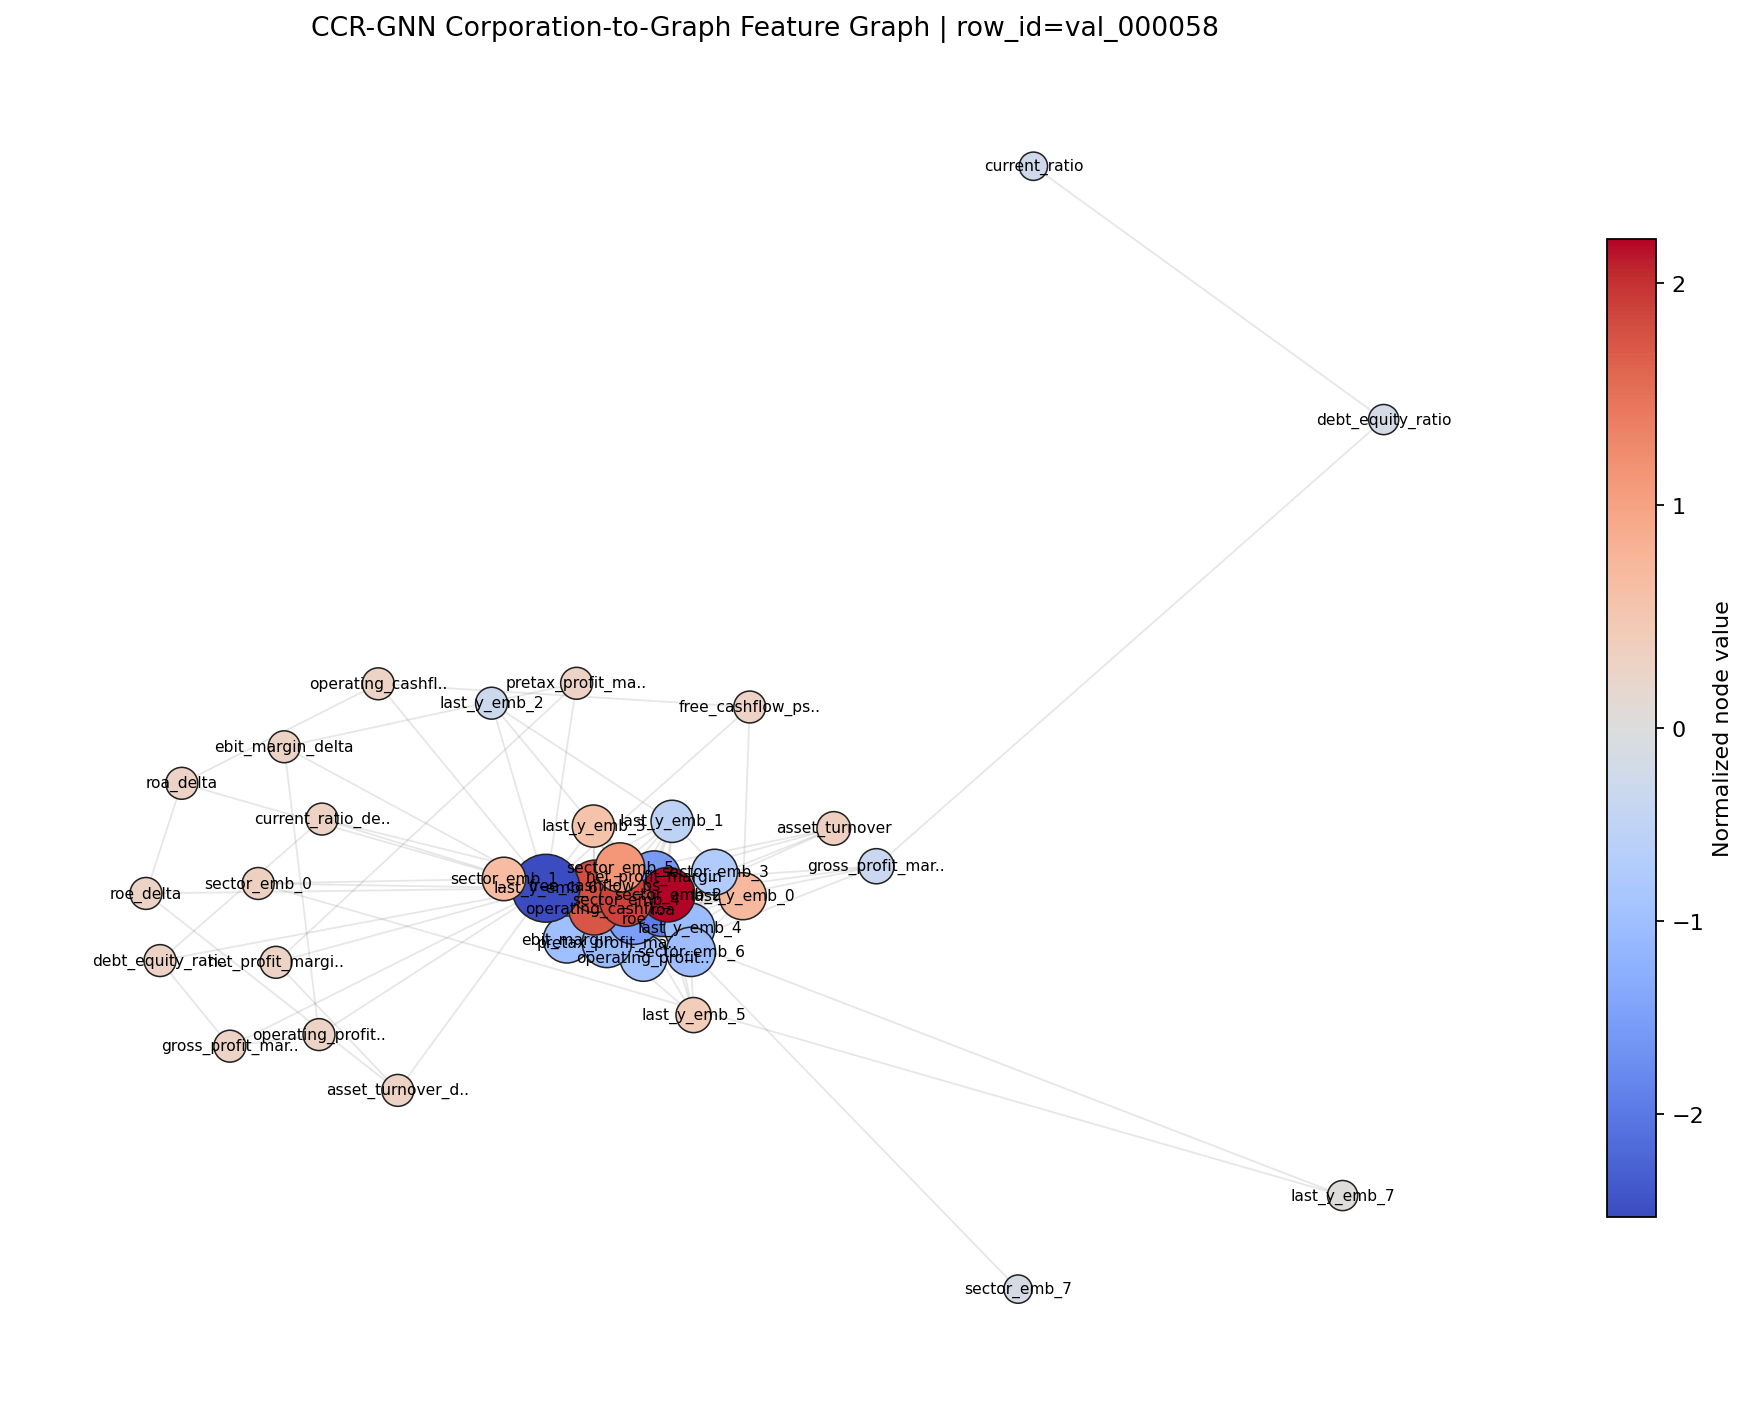

Feature nodes: 40 | feature edges: 192
Saved: /kaggle/working/credit_rating_artifacts/gat_graph_visualization.png


In [6]:
# Visualization: one corporation-to-graph feature graph.
# Yeu cau: chay cell model truoc. Rerun cell nay sau training neu muon xem graph voi embedding da hoc.
if 'model' not in globals() or 'FEATURE_NODE_NAMES' not in globals():
    raise RuntimeError('Khong tim thay model hoac FEATURE_NODE_NAMES. Hay chay cell cau hinh va cell model truoc.')

import networkx as nx
from matplotlib.colors import Normalize, TwoSlopeNorm

sample_candidates = np.flatnonzero(df['__split__'].eq('val').values)
sample_idx = int(sample_candidates[0]) if len(sample_candidates) else 0

model_was_training = model.training
model.eval()
with torch.no_grad():
    sample_nodes = model.build_node_values(
        x_all[sample_idx:sample_idx + 1],
        last_y_all[sample_idx:sample_idx + 1],
        sector_all[sample_idx:sample_idx + 1],
    )
    sample_adj = model.c2g_adjacency(sample_nodes)[0].detach().cpu().numpy().astype(bool)
    sample_values = sample_nodes[0, :, 0].detach().cpu().numpy()
if model_was_training:
    model.train()

edge_rows = []
for src in range(sample_adj.shape[0]):
    for dst in range(src + 1, sample_adj.shape[1]):
        if sample_adj[src, dst] or sample_adj[dst, src]:
            edge_rows.append({
                'src': src,
                'dst': dst,
                'src_feature': FEATURE_NODE_NAMES[src],
                'dst_feature': FEATURE_NODE_NAMES[dst],
                'outer_abs': float(abs(sample_values[src] * sample_values[dst])),
            })
feature_edge_df = pd.DataFrame(edge_rows).sort_values('outer_abs', ascending=False).reset_index(drop=True)
display(feature_edge_df.head(20))

G = nx.Graph()
for idx, name in enumerate(FEATURE_NODE_NAMES):
    G.add_node(idx, label=name, value=float(sample_values[idx]))
for row in edge_rows:
    G.add_edge(int(row['src']), int(row['dst']), weight=float(row['outer_abs']))

fig, ax = plt.subplots(figsize=(12, 9), dpi=160)
pos = nx.spring_layout(G, seed=SEED, k=0.55, iterations=120)
degrees = dict(G.degree())
node_sizes = [140 + 22 * degrees.get(n, 0) for n in G.nodes]
node_values = [G.nodes[n]['value'] for n in G.nodes]
if min(node_values) < 0 < max(node_values):
    color_norm = TwoSlopeNorm(vmin=min(node_values), vcenter=0.0, vmax=max(node_values))
else:
    color_norm = Normalize(vmin=min(node_values), vmax=max(node_values))
node_colors = plt.get_cmap('coolwarm')(color_norm(node_values))
nx.draw_networkx_edges(G, pos, alpha=0.18, width=0.8, edge_color='#777777', ax=ax)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    linewidths=0.7,
    edgecolors='#222222',
    ax=ax,
)
labels = {
    n: (G.nodes[n]['label'] if len(G.nodes[n]['label']) <= 18 else G.nodes[n]['label'][:16] + '..')
    for n in G.nodes
}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)
colorbar = plt.cm.ScalarMappable(cmap='coolwarm', norm=color_norm)
colorbar.set_array([])
fig.colorbar(colorbar, ax=ax, shrink=0.72, label='Normalized node value')
ax.set_title(f'CCR-GNN Corporation-to-Graph Feature Graph | row_id={df.loc[sample_idx, "row_id"]}')
ax.axis('off')
fig.tight_layout()
graph_path = ARTIFACT_DIR / 'gat_graph_visualization.png'
fig.savefig(graph_path, dpi=300, bbox_inches='tight')
plt.show()

print('Feature nodes:', len(FEATURE_NODE_NAMES), '| feature edges:', len(feature_edge_df))
print('Saved:', graph_path)


In [7]:
history = {
    'epoch': [],
    'train_Loss': [], 'val_Loss': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_Class0_Precision': [], 'val_Class0_Precision': [],
    'train_Class0_Recall': [], 'val_Class0_Recall': [],
    'train_Class0_F1': [], 'val_Class0_F1': [],
    'train_Class0_F2': [], 'val_Class0_F2': [],
    'train_ChgAcc': [], 'val_ChgAcc': [],
    'train_Ordinal_MAE': [], 'val_Ordinal_MAE': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
    'Learning_Rate': [],
}


def checkpoint_score(metrics, val_loss, train_loss):
    # Prefer good validation metrics, but penalize high validation loss and loss gap.
    loss_gap = max(0.0, float(val_loss) - float(train_loss))
    return selection_score(metrics) - 0.08 * float(val_loss) - 0.03 * loss_gap


best_val_score = -1.0
best_state = None
patience, no_improve = 100, 0
max_epochs = 100

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    logits = model(x_all, last_y_all, sector_all)
    loss = criterion(logits[train_mask], y_all[train_mask], epoch=epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_eval = model(x_all, last_y_all, sector_all)
        train_loss = criterion(logits_eval[train_mask], y_all[train_mask], epoch=epoch).item()
        val_loss = criterion(logits_eval[val_mask], y_all[val_mask], epoch=epoch).item()
        tr, _, _, _ = evaluate_logits(logits_eval, train_mask)
        va, _, _, _ = evaluate_logits(logits_eval, val_mask)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_Loss'].append(float(train_loss))
    history['val_Loss'].append(float(val_loss))
    history['Learning_Rate'].append(float(current_lr))
    for metric_name in ['Accuracy', 'Macro_F1', 'Class0_Precision', 'Class0_Recall', 'Class0_F1', 'Class0_F2', 'ChgAcc', 'Ordinal_MAE', 'AUC', 'QWK']:
        history[f'train_{metric_name}'].append(float(tr[metric_name]) if not (isinstance(tr[metric_name], float) and tr[metric_name] != tr[metric_name]) else float('nan'))
        history[f'val_{metric_name}'].append(float(va[metric_name]) if not (isinstance(va[metric_name], float) and va[metric_name] != va[metric_name]) else float('nan'))

    val_metric_score = selection_score(va)
    val_selection_score = checkpoint_score(va, val_loss, train_loss)
    print(
        f"Epoch {epoch:03d} | TrLoss {train_loss:.4f} | VaLoss {val_loss:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | "
        f"VaC0R {va['Class0_Recall']:.4f} | VaC0F2 {va['Class0_F2']:.4f} | "
        f"VaQWK {va['QWK']:.4f} | MetricScore {val_metric_score:.4f} | "
        f"CkptScore {val_selection_score:.4f} | LR {current_lr:.2e}"
    )

    if val_selection_score > best_val_score + 1e-4:
        best_val_score = val_selection_score
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print('Early stopping.')
            break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    final_logits, node_embeddings = model(x_all, last_y_all, sector_all, return_embeddings=True)

val_raw_metrics, y_val, y_val_raw_pred, val_proba = evaluate_logits(final_logits, val_mask)
test_raw_metrics, y_test, y_test_raw_pred, test_proba = evaluate_logits(final_logits, test_mask)

val_last_y = last_y_all[val_mask].detach().cpu().numpy()
test_last_y = last_y_all[test_mask].detach().cpu().numpy()

class0_threshold = None
class0_threshold_sweep = pd.DataFrame()
class0_threshold_baseline = val_raw_metrics
class0_threshold_selected = {}
if CLASS0_THRESHOLD_CONFIG['enabled']:
    class0_threshold, class0_threshold_sweep, class0_threshold_baseline, class0_threshold_selected = calibrate_class0_threshold(
        y_val,
        val_proba,
        last_y=val_last_y,
        config=CLASS0_THRESHOLD_CONFIG,
    )

val_metrics, y_val, y_val_pred, val_proba = evaluate_logits(final_logits, val_mask, class0_threshold=class0_threshold)
test_metrics, y_test, y_test_pred, test_proba = evaluate_logits(final_logits, test_mask, class0_threshold=class0_threshold)

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'gat_training_history.csv'
history_df.to_csv(history_path, index=False, encoding='utf-8-sig')

report = pd.DataFrame([
    {'Split': 'Val_RawArgmax', 'Class0_Threshold': np.nan, **val_raw_metrics},
    {'Split': 'Test_RawArgmax', 'Class0_Threshold': np.nan, **test_raw_metrics},
    {'Split': 'Val_Class0Calibrated', 'Class0_Threshold': class0_threshold, **val_metrics},
    {'Split': 'Test_Class0Calibrated', 'Class0_Threshold': class0_threshold, **test_metrics},
])
display(report)

metrics_path = ARTIFACT_DIR / 'gat_metrics.csv'
report.to_csv(metrics_path, index=False, encoding='utf-8-sig')

threshold_sweep_path = ARTIFACT_DIR / 'gat_class0_threshold_sweep.csv'
class0_threshold_sweep.to_csv(threshold_sweep_path, index=False, encoding='utf-8-sig')

threshold_summary_path = ARTIFACT_DIR / 'gat_class0_threshold_summary.csv'
pd.DataFrame([{
    'selected_threshold': class0_threshold,
    'selection_metric': CLASS0_THRESHOLD_CONFIG['metric'],
    'accuracy_floor_drop': CLASS0_THRESHOLD_CONFIG['accuracy_floor_drop'],
    **{f'val_selected_{k}': v for k, v in class0_threshold_selected.items() if isinstance(v, (int, float, np.integer, np.floating))},
}]).to_csv(threshold_summary_path, index=False, encoding='utf-8-sig')

print('Selected class 0 threshold:', class0_threshold)
print('Saved:', metrics_path)
print('Saved:', history_path)
print('Saved:', threshold_sweep_path)
print('Saved:', threshold_summary_path)


Epoch 001 | TrLoss 0.7698 | VaLoss 0.8251 | VaAcc 0.7819 | VaF1 0.5074 | VaC0R 0.0000 | VaC0F2 0.0000 | VaQWK 0.4574 | MetricScore 0.5934 | CkptScore 0.5257 | LR 1.20e-03
Epoch 002 | TrLoss 0.5691 | VaLoss 0.6309 | VaAcc 0.8225 | VaF1 0.5892 | VaC0R 0.1000 | VaC0F2 0.1136 | VaQWK 0.5687 | MetricScore 0.6504 | CkptScore 0.5980 | LR 1.20e-03
Epoch 003 | TrLoss 0.4463 | VaLoss 0.5083 | VaAcc 0.8840 | VaF1 0.7142 | VaC0R 0.3333 | VaC0F2 0.3472 | VaQWK 0.7432 | MetricScore 0.7483 | CkptScore 0.7058 | LR 1.20e-03
Epoch 004 | TrLoss 0.3979 | VaLoss 0.4565 | VaAcc 0.9072 | VaF1 0.7588 | VaC0R 0.4333 | VaC0F2 0.4422 | VaQWK 0.8019 | MetricScore 0.7826 | CkptScore 0.7443 | LR 1.20e-03
Epoch 005 | TrLoss 0.3771 | VaLoss 0.4223 | VaAcc 0.9130 | VaF1 0.7816 | VaC0R 0.5000 | VaC0F2 0.5068 | VaQWK 0.8291 | MetricScore 0.7971 | CkptScore 0.7620 | LR 1.20e-03
Epoch 006 | TrLoss 0.3747 | VaLoss 0.4031 | VaAcc 0.9165 | VaF1 0.8208 | VaC0R 0.6333 | VaC0F2 0.6333 | VaQWK 0.8418 | MetricScore 0.8179 | CkptS

,Split,Class0_Threshold,Accuracy,Precision_Weighted,Recall_Weighted,Macro_F1,Weighted_F1,Class0_Precision,Class0_Recall,Class0_F1,Class0_F2,Class0_Support,AUC,QWK,ChgAcc,Ordinal_MAE
0,Val_RawArgmax,NaN,0.922274,0.923859,0.922274,0.838536,0.922911,0.628571,0.733333,0.676923,0.709677,30,0.953635,0.871099,0.000000,0.078886
1,Test_RawArgmax,NaN,0.923389,0.924133,0.923389,0.832525,0.923714,0.650000,0.661017,0.655462,0.658784,59,0.952031,0.872974,0.015385,0.077191
2,Val_Class0Calibrated,0.26,0.922274,0.923859,0.922274,0.838536,0.922911,0.628571,0.733333,0.676923,0.709677,30,0.953635,0.871099,0.000000,0.078886
3,Test_Class0Calibrated,0.26,0.922229,0.923273,0.922229,0.828253,0.922701,0.629032,0.661017,0.644628,0.654362,59,0.952031,0.871627,0.000000,0.078352


Selected class 0 threshold: 0.26
Saved: /kaggle/working/credit_rating_artifacts/gat_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_training_history.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_class0_threshold_sweep.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_class0_threshold_summary.csv


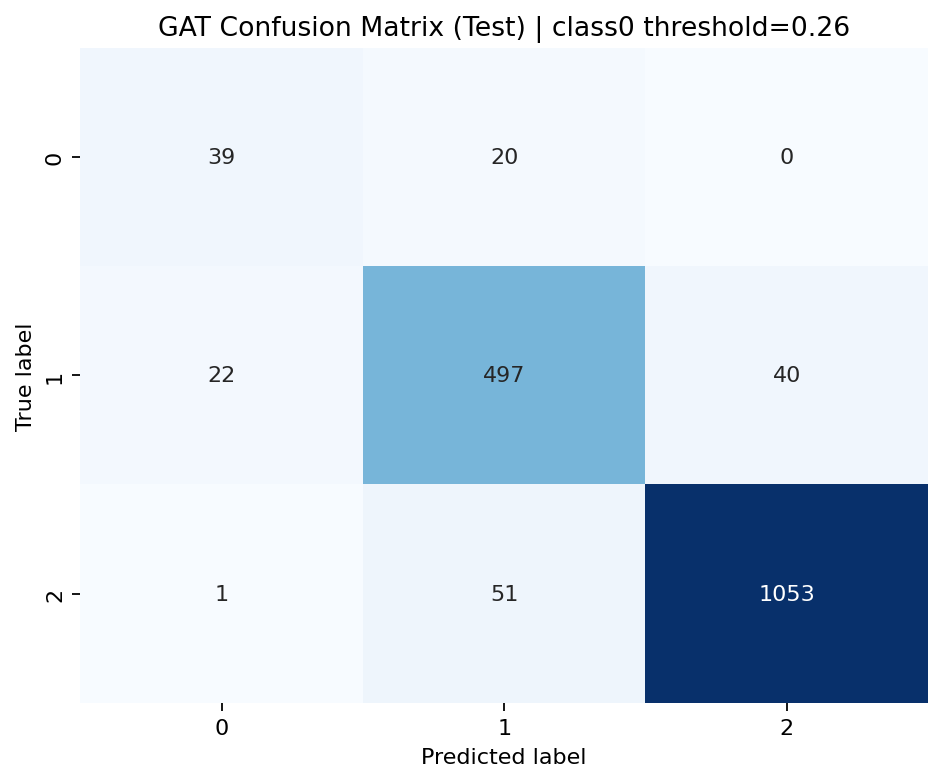

,0,1,2
0,39,20,0
1,22,497,40
2,1,51,1053


Classification report (test set, class 0 calibrated):
              precision    recall  f1-score   support

           0     0.6290    0.6610    0.6446        59
           1     0.8750    0.8891    0.8820       559
           2     0.9634    0.9529    0.9581      1105

    accuracy                         0.9222      1723
   macro avg     0.8225    0.8343    0.8283      1723
weighted avg     0.9233    0.9222    0.9227      1723

Raw argmax class 0 metrics:
{'Class0_Precision': 0.65, 'Class0_Recall': 0.661, 'Class0_F1': 0.6555, 'Accuracy': 0.9234}
Calibrated class 0 metrics:
{'Class0_Precision': 0.629, 'Class0_Recall': 0.661, 'Class0_F1': 0.6446, 'Accuracy': 0.9222}


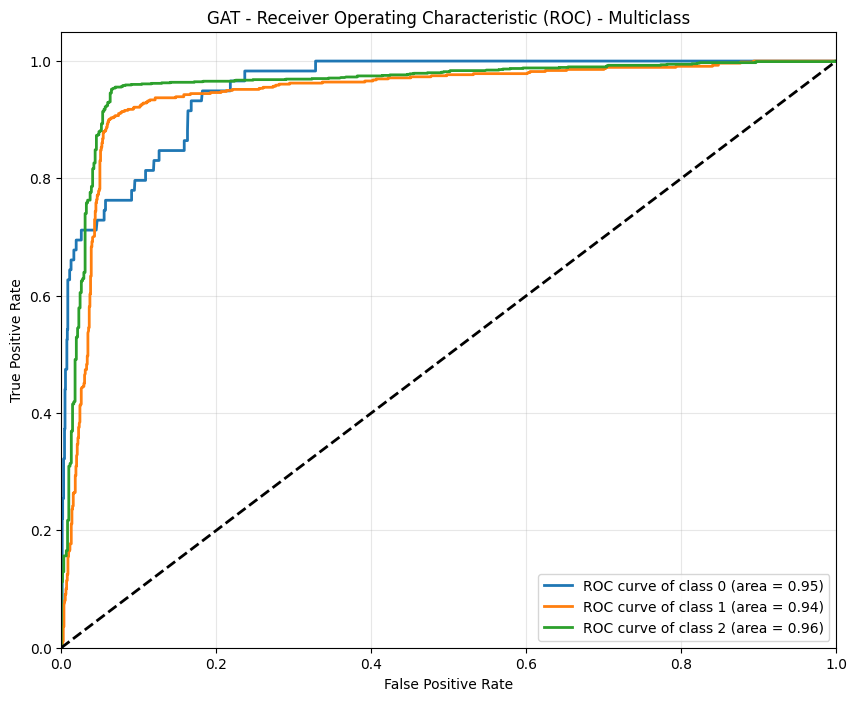

Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_classification_report.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_roc_curves.png


In [8]:
id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_test, y_test_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
threshold_title = f' | class0 threshold={class0_threshold:.2f}' if class0_threshold is not None else ''
plt.title(f'GAT Confusion Matrix (Test){threshold_title}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set, class 0 calibrated):')
print(classification_report(
    y_test,
    y_test_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

if 'test_raw_metrics' in globals():
    print('Raw argmax class 0 metrics:')
    print({
        'Class0_Precision': round(test_raw_metrics['Class0_Precision'], 4),
        'Class0_Recall': round(test_raw_metrics['Class0_Recall'], 4),
        'Class0_F1': round(test_raw_metrics['Class0_F1'], 4),
        'Accuracy': round(test_raw_metrics['Accuracy'], 4),
    })
    print('Calibrated class 0 metrics:')
    print({
        'Class0_Precision': round(test_metrics['Class0_Precision'], 4),
        'Class0_Recall': round(test_metrics['Class0_Recall'], 4),
        'Class0_F1': round(test_metrics['Class0_F1'], 4),
        'Accuracy': round(test_metrics['Accuracy'], 4),
    })

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'gat_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GAT - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'gat_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)
print('Saved:', roc_plot_path)


In [9]:
# Export prediction CSVs with the same contract as LSTM for DMF/DCS.

def prediction_frame(split_name, split_mask, y_true, proba, pred=None, class0_threshold=None):
    pred = predict_with_class0_threshold(proba, class0_threshold=class0_threshold) if pred is None else np.asarray(pred).astype(int)
    raw_pred = np.argmax(proba, axis=1).astype(int)
    conf = proba[np.arange(len(pred)), pred]
    rows = df.loc[split_mask.detach().cpu().numpy(), ['row_id', 'ticker', 'company_name', 'rating_date']].copy().reset_index(drop=True)
    rows.insert(0, 'split', split_name)
    rows['rating_date'] = pd.to_datetime(rows['rating_date'], errors='coerce').dt.strftime('%Y-%m-%d').fillna('')
    rows['true_label'] = y_true.astype(int)
    rows['true_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in y_true]
    rows['pred_label'] = pred
    rows['pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in pred]
    rows['raw_pred_label'] = raw_pred
    rows['raw_pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in raw_pred]
    rows['class0_threshold'] = np.nan if class0_threshold is None else float(class0_threshold)
    rows['confidence'] = conf.astype(float)
    rows['raw_confidence'] = np.max(proba, axis=1).astype(float)
    for cls_idx in range(proba.shape[1]):
        rows[f'prob_{cls_idx}'] = proba[:, cls_idx].astype(float)
    return rows


gat_val_predictions = prediction_frame('val', val_mask, y_val, val_proba, pred=y_val_pred, class0_threshold=class0_threshold)
gat_test_predictions = prediction_frame('test', test_mask, y_test, test_proba, pred=y_test_pred, class0_threshold=class0_threshold)

val_csv = DMF_ARTIFACT_DIR / 'gat_val_predictions.csv'
test_csv = DMF_ARTIFACT_DIR / 'gat_test_predictions.csv'
gat_val_predictions.to_csv(val_csv, index=False, encoding='utf-8-sig')
gat_test_predictions.to_csv(test_csv, index=False, encoding='utf-8-sig')

np.save(DMF_ARTIFACT_DIR / 'gat_val_embeddings.npy', node_embeddings[val_mask].detach().cpu().numpy())
np.save(DMF_ARTIFACT_DIR / 'gat_test_embeddings.npy', node_embeddings[test_mask].detach().cpu().numpy())
np.save(ARTIFACT_DIR / 'gat_val_proba.npy', val_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_test_proba.npy', test_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_y_val.npy', y_val.astype(int))
np.save(ARTIFACT_DIR / 'gat_y_test.npy', y_test.astype(int))

label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')
print(f'[OK] Saved DMF val CSV  -> {val_csv}')
print(f'[OK] Saved DMF test CSV -> {test_csv}')
print(gat_test_predictions.head())


[OK] Saved DMF val CSV  -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_val_predictions.csv
[OK] Saved DMF test CSV -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_test_predictions.csv
  split       row_id ticker                   company_name rating_date  \
0  test  test_000040    AAL  American Airlines Group, Inc.  2013-11-12   
1  test  test_000815    AAP       ADVANCE AUTO PARTS, INC.  2013-05-29   
2  test  test_000326    AAP       Advance Auto Parts, Inc.  2013-11-25   
3  test  test_000813   AAPL                     Apple Inc.  2015-05-28   
4  test  test_000387   AAPL                     Apple Inc.  2016-06-03   

   true_label true_label_name  pred_label pred_label_name  raw_pred_label  \
0           1               1           1               1               1   
1           2               2           2               2               2   
2           2               2           2               2               2   
3           2               2         

In [10]:
# Diagnostics: class 0 threshold trade-off and false negatives.
if 'class0_threshold_sweep' not in globals() or class0_threshold_sweep.empty:
    raise RuntimeError('Chua co class0_threshold_sweep. Hay chay lai cell huan luyen truoc.')

display_cols = [
    'class0_threshold', 'Accuracy', 'Macro_F1',
    'Class0_Precision', 'Class0_Recall', 'Class0_F1', 'Class0_F2',
]
threshold_view = class0_threshold_sweep[display_cols].sort_values(
    ['Class0_F2', 'Accuracy', 'Macro_F1'],
    ascending=False,
).head(12)
display(threshold_view)

class0_tradeoff_path = ARTIFACT_DIR / 'gat_class0_threshold_top_candidates.csv'
threshold_view.to_csv(class0_tradeoff_path, index=False, encoding='utf-8-sig')

test_rows = df.loc[test_mask.detach().cpu().numpy(), [
    'row_id', 'ticker', 'company_name', 'rating_date', 'sector',
    TARGET_COL, 'last_y',
]].copy().reset_index(drop=True)
test_rows['pred_label'] = y_test_pred.astype(int)
test_rows['raw_pred_label'] = y_test_raw_pred.astype(int)
for cls_idx in range(test_proba.shape[1]):
    test_rows[f'prob_{cls_idx}'] = test_proba[:, cls_idx]

class0_error_mask = (test_rows[TARGET_COL].astype(int) == CLASS0_LABEL_ID) & (test_rows['pred_label'] != CLASS0_LABEL_ID)
class0_false_negatives = test_rows.loc[class0_error_mask].sort_values('prob_0', ascending=False)
class0_false_negative_path = ARTIFACT_DIR / 'gat_class0_false_negatives.csv'
class0_false_negatives.to_csv(class0_false_negative_path, index=False, encoding='utf-8-sig')

print('Class 0 confusion by last_y:')
display(pd.crosstab(
    test_rows.loc[test_rows[TARGET_COL].astype(int).eq(CLASS0_LABEL_ID), 'last_y'],
    test_rows.loc[test_rows[TARGET_COL].astype(int).eq(CLASS0_LABEL_ID), 'pred_label'],
    rownames=['last_y'],
    colnames=['pred_label'],
))

print('Top class 0 false negatives by prob_0:')
display(class0_false_negatives.head(20))

print('Saved:', class0_tradeoff_path)
print('Saved:', class0_false_negative_path)


,class0_threshold,Accuracy,Macro_F1,Class0_Precision,Class0_Recall,Class0_F1,Class0_F2
21,0.26,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
22,0.27,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
23,0.28,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
24,0.29,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
25,0.30,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
26,0.31,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
27,0.32,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
28,0.33,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
29,0.34,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677
30,0.35,0.922274,0.838536,0.628571,0.733333,0.676923,0.709677


Class 0 confusion by last_y:


pred_label,0,1
last_y,,
0,39,0
1,0,20


Top class 0 false negatives by prob_0:


,row_id,ticker,company_name,rating_date,sector,rating_detail,last_y,pred_label,raw_pred_label,prob_0,prob_1,prob_2
205,test_001604,BTE,Baytex Energy Corp,2016-02-03,5,0,1,1,1,0.194980,0.660840,0.144181
1105,test_001606,NRP,Natural Resource Partners LP,2016-06-01,5,0,1,1,1,0.173908,0.643486,0.182606
230,test_001293,BZH,"Beazer Homes USA, Inc.",2012-09-06,8,0,1,1,1,0.114629,0.821078,0.064293
1524,test_001666,THC,Tenet Healthcare Corp.,2015-07-08,7,0,1,1,1,0.060886,0.906952,0.032162
1521,test_000747,THC,Tenet Healthcare Corp.,2014-03-05,7,0,1,1,1,0.051741,0.920085,0.028174
63,test_000034,AMD,"Advanced Micro Devices, Inc.",2015-04-21,10,0,1,1,1,0.050660,0.891418,0.057922
232,test_000860,BZH,Beazer Homes USA Inc.,2014-06-13,8,0,1,1,1,0.035545,0.954650,0.009804
209,test_001714,BTU,PEABODY ENERGY CORPORATION,2014-10-22,5,0,1,1,1,0.034694,0.936350,0.028955
872,test_000078,KTOS,"Kratos Defense & Security Solutions, Inc.",2016-12-16,1,0,1,1,1,0.030546,0.941908,0.027546
1487,test_000811,TECK,Teck Resources Limited,2016-05-23,8,0,1,1,1,0.027371,0.924120,0.048509


Saved: /kaggle/working/credit_rating_artifacts/gat_class0_threshold_top_candidates.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_class0_false_negatives.csv


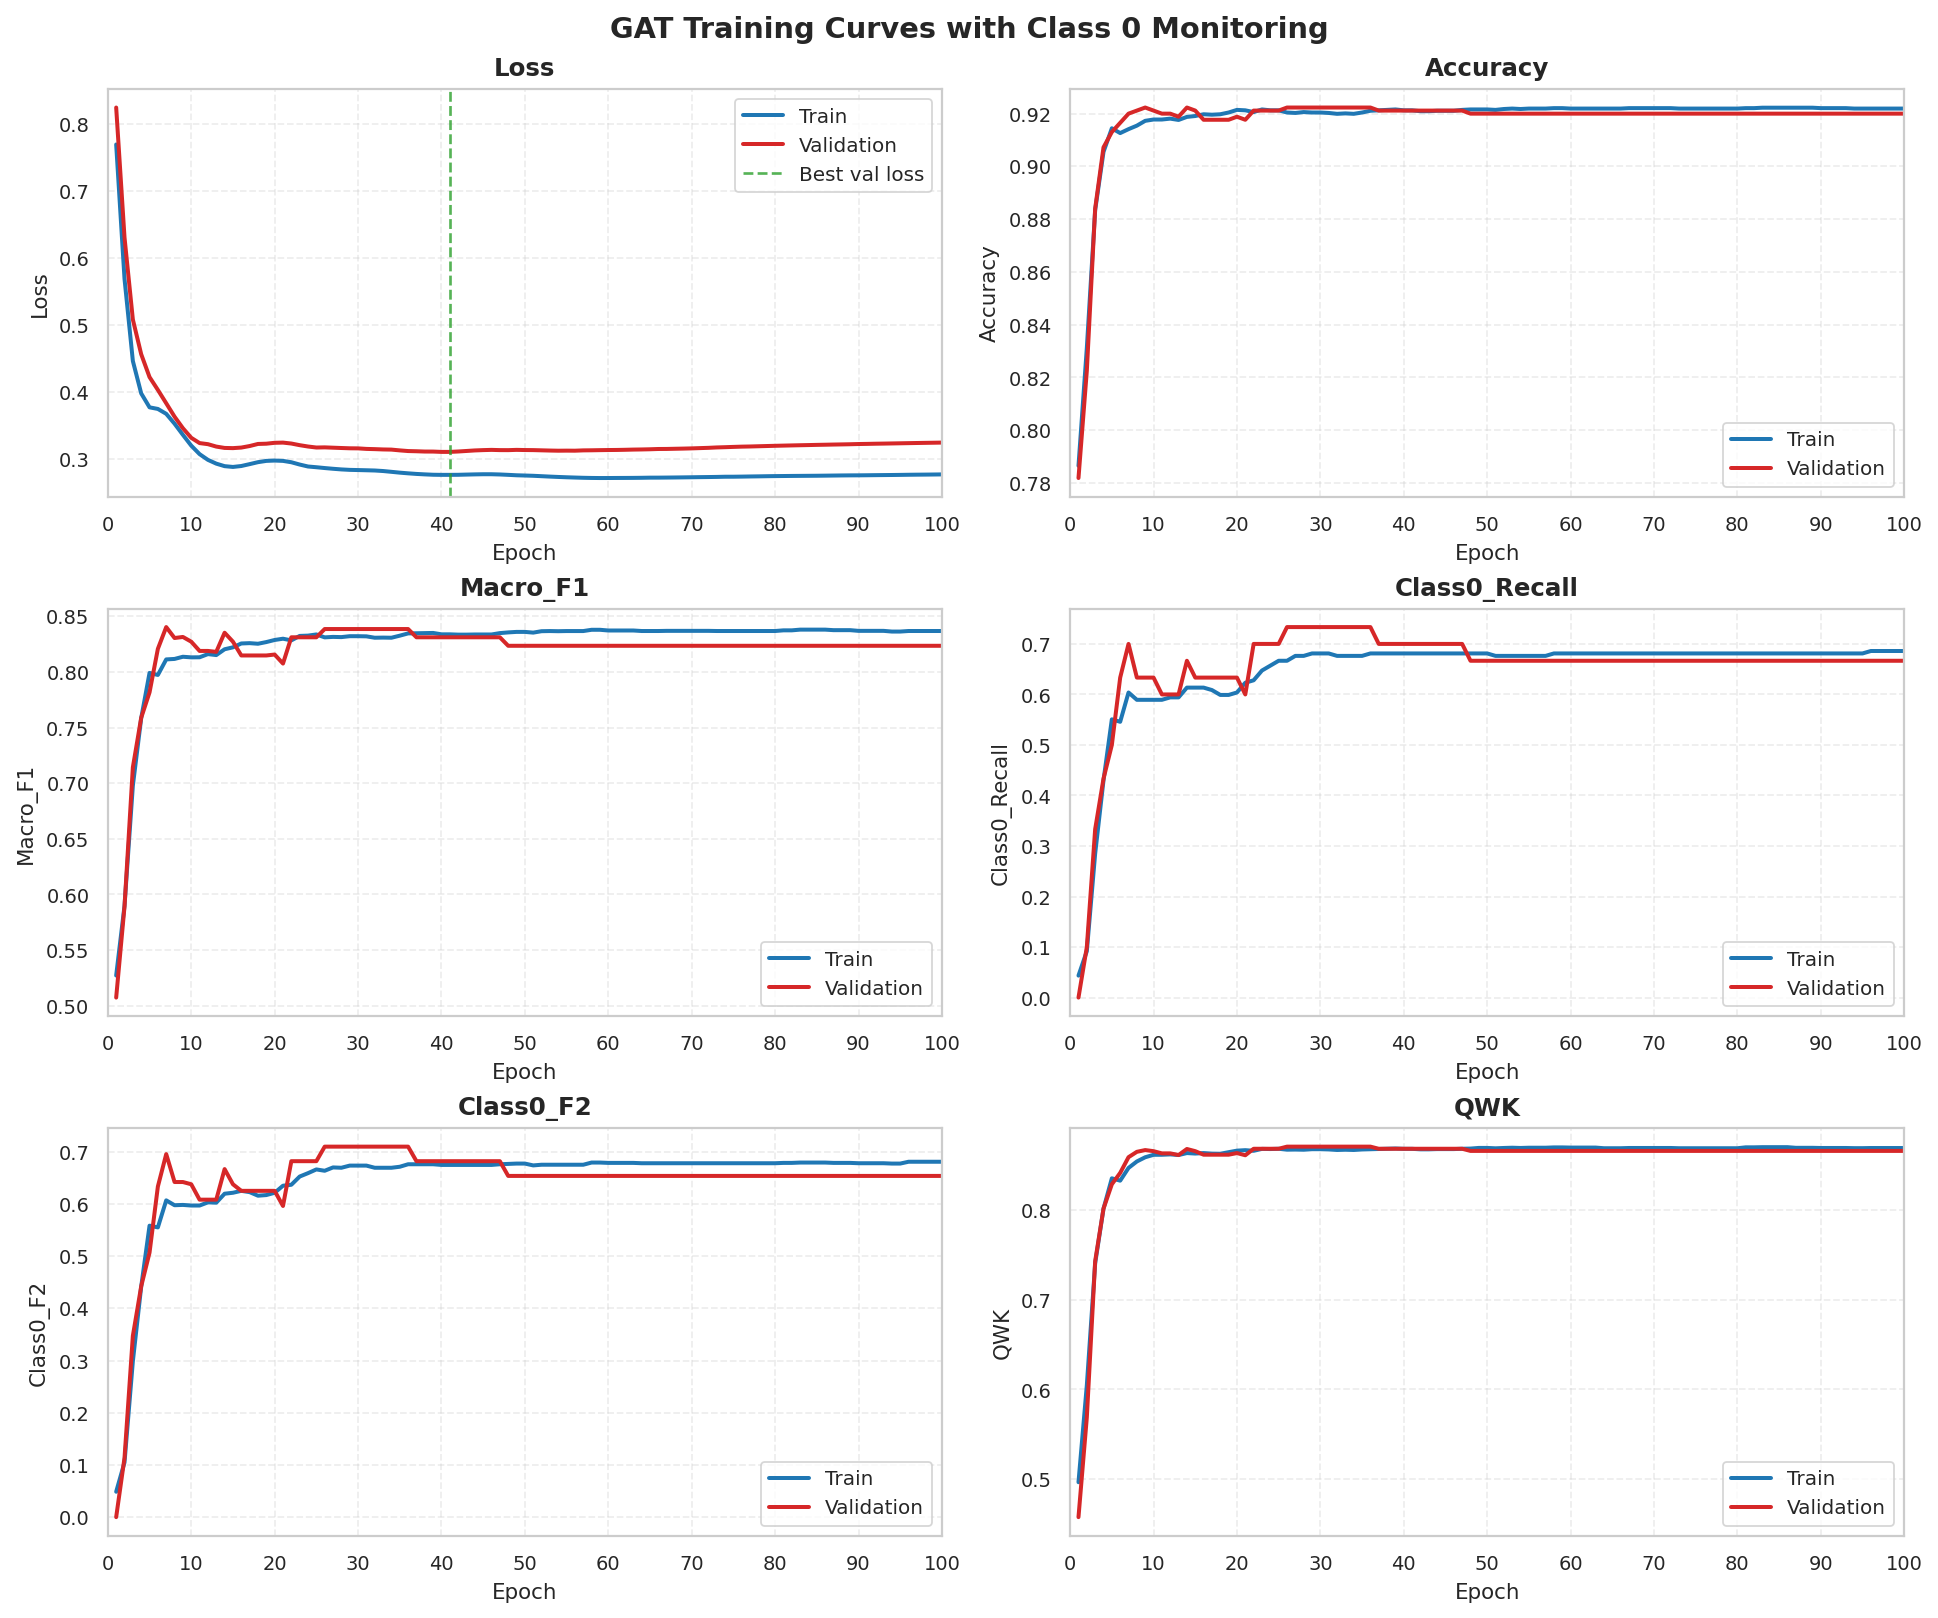

Saved: /kaggle/working/credit_rating_artifacts/gat_training_curves.png


In [11]:
# Visualization: training curves
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

from matplotlib.ticker import MultipleLocator

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'Class0_Recall', 'Class0_F2', 'QWK']
required_cols = [f'train_{m}' for m in metrics] + [f'val_{m}' for m in metrics]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()
max_epoch = int(history_df['epoch'].max())

for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label='Validation', linewidth=1.8, color='#d62728')
    if metric == 'Loss':
        best_epoch = int(history_df.loc[history_df['val_Loss'].idxmin(), 'epoch'])
        ax.axvline(best_epoch, color='#2ca02c', linestyle='--', linewidth=1.2, alpha=0.8, label='Best val loss')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, max_epoch)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle('GAT Training Curves with Class 0 Monitoring', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'gat_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)


In [12]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

history_df = history_df.copy()
history_df['val_MetricScore'] = history_df.apply(
    lambda row: selection_score({
        'Accuracy': row['val_Accuracy'],
        'QWK': row['val_QWK'],
        'Macro_F1': row['val_Macro_F1'],
        'Class0_F2': row['val_Class0_F2'],
        'ChgAcc': row['val_ChgAcc'],
        'Ordinal_MAE': row['val_Ordinal_MAE'],
    }),
    axis=1,
)
history_df['val_CheckpointScore'] = history_df.apply(
    lambda row: checkpoint_score(
        {
            'Accuracy': row['val_Accuracy'],
            'QWK': row['val_QWK'],
            'Macro_F1': row['val_Macro_F1'],
            'Class0_F2': row['val_Class0_F2'],
            'ChgAcc': row['val_ChgAcc'],
            'Ordinal_MAE': row['val_Ordinal_MAE'],
        },
        row['val_Loss'],
        row['train_Loss'],
    ),
    axis=1,
)
best_epoch_idx = history_df['val_CheckpointScore'].idxmax()
min_val_loss_idx = history_df['val_Loss'].idxmin()
best_epoch = int(history_df.loc[best_epoch_idx, 'epoch']) if 'epoch' in history_df.columns else int(best_epoch_idx) + 1
min_val_loss_epoch = int(history_df.loc[min_val_loss_idx, 'epoch']) if 'epoch' in history_df.columns else int(min_val_loss_idx) + 1

row = history_df.loc[best_epoch_idx]
best_train_loss = float(row['train_Loss'])
best_val_loss = float(row['val_Loss'])
best_train_acc = float(row['train_Accuracy'])
best_val_acc = float(row['val_Accuracy'])
best_val_class0_recall = float(row['val_Class0_Recall'])
best_val_class0_f2 = float(row['val_Class0_F2'])

print('Best metrics (by loss-aware validation checkpoint score):')
print(f'Train Loss:       {best_train_loss:.6f} @ epoch {best_epoch}')
print(f'Val Loss:         {best_val_loss:.6f} @ epoch {best_epoch}')
print(f'Train Acc:        {best_train_acc:.6f} @ epoch {best_epoch}')
print(f'Val Acc:          {best_val_acc:.6f} @ epoch {best_epoch}')
print(f'Val Class0 Recall:{best_val_class0_recall:.6f} @ epoch {best_epoch}')
print(f'Val Class0 F2:    {best_val_class0_f2:.6f} @ epoch {best_epoch}')
print(f'Min Val Loss:     {float(history_df.loc[min_val_loss_idx, "val_Loss"]):.6f} @ epoch {min_val_loss_epoch}')

summary_df = pd.DataFrame([
    {
        'epoch': best_epoch,
        'train_loss': best_train_loss,
        'val_loss': best_val_loss,
        'train_acc': best_train_acc,
        'val_acc': best_val_acc,
        'val_class0_recall': best_val_class0_recall,
        'val_class0_f2': best_val_class0_f2,
        'val_metric_score': float(row['val_MetricScore']),
        'val_checkpoint_score': float(row['val_CheckpointScore']),
        'min_val_loss_epoch': min_val_loss_epoch,
        'min_val_loss': float(history_df.loc[min_val_loss_idx, 'val_Loss']),
        'learning_rate': float(row['Learning_Rate']) if 'Learning_Rate' in row else np.nan,
        'selected_class0_threshold': class0_threshold if 'class0_threshold' in globals() else np.nan,
    }
])

training_summary_path = ARTIFACT_DIR / 'gat_training_summary.csv'
summary_df.to_csv(training_summary_path, index=False, encoding='utf-8-sig')
display(summary_df)
print('Saved:', training_summary_path)


Best metrics (by loss-aware validation checkpoint score):
Train Loss:       0.278488 @ epoch 36
Val Loss:         0.311786 @ epoch 36
Train Acc:        0.921048 @ epoch 36
Val Acc:          0.922274 @ epoch 36
Val Class0 Recall:0.733333 @ epoch 36
Val Class0 F2:    0.709677 @ epoch 36
Min Val Loss:     0.310516 @ epoch 41


,epoch,train_loss,val_loss,train_acc,val_acc,val_class0_recall,val_class0_f2,val_metric_score,val_checkpoint_score,min_val_loss_epoch,min_val_loss,learning_rate,selected_class0_threshold
0,36,0.278488,0.311786,0.921048,0.922274,0.733333,0.709677,0.834906,0.808964,41,0.310516,0.00066,0.26


Saved: /kaggle/working/credit_rating_artifacts/gat_training_summary.csv
